In [3]:
import pandas as pd
import os

In [4]:
data_path = "Raw data"

# Load and combine all files


In [5]:
# get all csv that start with "data"
all_files = [f for f in os.listdir(data_path) if f.startswith("data-") and f.endswith(".csv")]
print(f"Found {len(all_files)} files")

#os.listdir()- gives all files names iin folder

Found 82 files


In [6]:
# Load and combine
dfs = []
for file in all_files:
    file_path = os.path.join(data_path, file)
    df = pd.read_csv(
        file_path,
        header=None,
        names=["site_id", "richting", "type", "van", "tot", "aantal"]
    )
    dfs.append(df)
    
df = pd.concat(dfs, ignore_index=True)

When pandas reads csv: treats everything a text by default (we still have to convert again to datetime)

In [7]:
df["van"] = pd.to_datetime(df["van"])
df["tot"] = pd.to_datetime(df["tot"])

In [8]:
# Filter cyclists only
df = df[df["type"] == "FIETSERS"]

In [9]:
# Counts as integer
df["aantal"] = df["aantal"].fillna(0).astype(int)

In [10]:
# Basic stats
print(f"\nTotal rows: {len(df):,}")
print(f"Date range: {df['van'].min()} to {df['van'].max()}")
print(f"Unique sites: {df['site_id'].nunique()}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nSample:\n{df.head()}")


Total rows: 43,096,270
Date range: 2019-08-01 00:00:00 to 2026-05-17 03:15:00
Unique sites: 150

Missing values:
site_id     0
richting    0
type        0
van         0
tot         0
aantal      0
dtype: int64

Sample:
   site_id richting      type                 van                 tot  aantal
0        1       IN  FIETSERS 2019-08-01 00:00:00 2019-08-01 00:15:00       0
1        1       IN  FIETSERS 2019-08-01 00:15:00 2019-08-01 00:30:00       0
2        1       IN  FIETSERS 2019-08-01 00:30:00 2019-08-01 00:45:00       0
3        1       IN  FIETSERS 2019-08-01 00:45:00 2019-08-01 01:00:00       0
4        1       IN  FIETSERS 2019-08-01 01:00:00 2019-08-01 01:15:00       1


In [11]:
# Convert intervals to hour timestamp since weather data is hourly
df["hour_timestamp"] = df["van"].dt.floor("h")

In [12]:
# Group rows by site and hour, then sum counts (we get site, hour, counts) + combine in and out into one as well 
hourly = df.groupby(["site_id", "hour_timestamp"]).agg(
    bike_count=("aantal", "sum")
).reset_index()

We then will extract input features for our model: 
hour (cycling peaks)

day of week (leisure vs commuting)

month (more cycling in summer)

year (long-term trends)

0-1 binary for weekend 1 if weekend;

In [13]:
# Add temporal features
hourly["hour"] = hourly["hour_timestamp"].dt.hour
hourly["day_of_week"] = hourly["hour_timestamp"].dt.dayofweek
hourly["month"] = hourly["hour_timestamp"].dt.month
hourly["year"] = hourly["hour_timestamp"].dt.year
hourly["is_weekend"] = hourly["day_of_week"].isin([5, 6]).astype(int)

In [14]:
# Check results
print(f"\nAggregated to {len(hourly):,} hourly rows")
print(f"Date range: {hourly['hour_timestamp'].min()} to {hourly['hour_timestamp'].max()}")
print(f"\nSample:\n{hourly.head(10)}")
print(f"\nBike count stats:\n{hourly['bike_count'].describe()}")


Aggregated to 5,387,137 hourly rows
Date range: 2019-08-01 00:00:00 to 2026-05-17 03:00:00

Sample:
   site_id      hour_timestamp  bike_count  hour  day_of_week  month  year  \
0        1 2019-08-01 00:00:00           2     0            3      8  2019   
1        1 2019-08-01 01:00:00           1     1            3      8  2019   
2        1 2019-08-01 02:00:00           1     2            3      8  2019   
3        1 2019-08-01 03:00:00           0     3            3      8  2019   
4        1 2019-08-01 04:00:00           2     4            3      8  2019   
5        1 2019-08-01 05:00:00           8     5            3      8  2019   
6        1 2019-08-01 06:00:00          34     6            3      8  2019   
7        1 2019-08-01 07:00:00          44     7            3      8  2019   
8        1 2019-08-01 08:00:00          42     8            3      8  2019   
9        1 2019-08-01 09:00:00          16     9            3      8  2019   

   is_weekend  
0           0  
1       

# Next step: Fetch weather data

The key trade-off: Open-Meteo is interpolated model data (smooth, no gaps, consistent), while Meteostat is real station measurements (more "true" locally, but with potential gaps). For a project covering all of Flanders with 150 sensor sites, Open-Meteo is the safer and simpler choice.

In [15]:
import requests

def fetch_openmeteo(start_date, end_date, lat=51.05, lon=3.72):
    """
    Fetch hourly historical weather from Open-Meteo for Flanders.
    Coordinates default to Ghent as central Flanders point.
    """

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,cloud_cover",
        "timezone": "Europe/Brussels"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    weather = pd.DataFrame({
    "hour_timestamp": pd.to_datetime(data["hourly"]["time"]),
    "temperature": data["hourly"]["temperature_2m"],
    "humidity": data["hourly"]["relative_humidity_2m"],
    "precipitation": data["hourly"]["precipitation"],
    "wind_speed": data["hourly"]["wind_speed_10m"],
    "cloud_cover": data["hourly"]["cloud_cover"]
    })

    return weather

What we ae doing here: 

We call the Open-Meteo archive API with our coordinates (Ghent, central Flanders) and date range

response.raise_for_status() — if the internet call failed, this throws an error immediately rather than silently giving bad data

The API returns a JSON object with a "hourly" key containing lists of values — one per hour

We zip those lists into a DataFrame, one row per hour

timezone="Europe/Brussels" ensures times match our sensor data (which is also local time)

In [16]:
# Fetch weather for the full date range of our data
weather = fetch_openmeteo("2019-08-01", "2026-05-17")

print(weather.head())

       hour_timestamp  temperature  humidity  precipitation  wind_speed  \
0 2019-08-01 00:00:00         16.7        72            0.0        15.4   
1 2019-08-01 01:00:00         16.4        76            0.0        15.8   
2 2019-08-01 02:00:00         16.5        81            0.0        15.1   
3 2019-08-01 03:00:00         15.9        84            0.0        14.7   
4 2019-08-01 04:00:00         15.4        88            0.0        14.2   

   cloud_cover  
0           46  
1           56  
2           49  
3           58  
4           12  


In [17]:
print(f"Weather rows: {len(weather):,}")
print(f"Date range: {weather['hour_timestamp'].min()} to {weather['hour_timestamp'].max()}")
print(f"\nSample:\n{weather.head()}")
print(f"\nMissing values:\n{weather.isna().sum()}")

Weather rows: 59,568
Date range: 2019-08-01 00:00:00 to 2026-05-17 23:00:00

Sample:
       hour_timestamp  temperature  humidity  precipitation  wind_speed  \
0 2019-08-01 00:00:00         16.7        72            0.0        15.4   
1 2019-08-01 01:00:00         16.4        76            0.0        15.8   
2 2019-08-01 02:00:00         16.5        81            0.0        15.1   
3 2019-08-01 03:00:00         15.9        84            0.0        14.7   
4 2019-08-01 04:00:00         15.4        88            0.0        14.2   

   cloud_cover  
0           46  
1           56  
2           49  
3           58  
4           12  

Missing values:
hour_timestamp    0
temperature       0
humidity          0
precipitation     0
wind_speed        0
cloud_cover       0
dtype: int64


Notice no missing data - that is why we use it instead of meteostat!

In [18]:
# Merge hourly cycling data with weather data
merged = pd.merge(
    hourly,
    weather,
    on="hour_timestamp",
    how="left"
)

print(f"Merged rows: {len(merged):,}")

print("\nSample:")
print(merged.head())

print("\nMissing values:")
print(merged.isna().sum())

Merged rows: 5,387,137

Sample:
   site_id      hour_timestamp  bike_count  hour  day_of_week  month  year  \
0        1 2019-08-01 00:00:00           2     0            3      8  2019   
1        1 2019-08-01 01:00:00           1     1            3      8  2019   
2        1 2019-08-01 02:00:00           1     2            3      8  2019   
3        1 2019-08-01 03:00:00           0     3            3      8  2019   
4        1 2019-08-01 04:00:00           2     4            3      8  2019   

   is_weekend  temperature  humidity  precipitation  wind_speed  cloud_cover  
0           0         16.7        72            0.0        15.4           46  
1           0         16.4        76            0.0        15.8           56  
2           0         16.5        81            0.0        15.1           49  
3           0         15.9        84            0.0        14.7           58  
4           0         15.4        88            0.0        14.2           12  

Missing values:
site_id 

Perfect! - no missing values; have aggregated site, hour-day-timestamp, bike count, weekend?, temperature, humidity, percipitation, wind_speed, cloud_cover

We also want to include long lat as features as we saw could improve the model 

In [19]:
# Load sites metadata to get coordinates
cols = [
    "site_id", "site_nr", "long", "lat", "naam", "domein",
    "wegnr", "district", "gemeente", "interval", "datum_van"
]
sites_meta = pd.read_csv(
    "sites.csv",
    names=cols,
    header=None
)

# Merge lat/lon into merged dataframe
merged = merged.merge(
    sites_meta[["site_id", "lat", "long"]],
    on="site_id",
    how="left"
)
merged = merged.rename(columns={"long": "lon"})

# Next Step: Train the regression model 

Let's start with XGBoost

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [25]:
# define features and target 

# Features used for prediction
features = [
    "lat",
    "lon",
    "hour",
    "day_of_week",
    "month",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "cloud_cover"
]

X = merged[features]

# Target variable
y = merged["bike_count"]

In [26]:
# Then split training, test 80% for training, 20% for validation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Then train
model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [28]:
# Evaluate
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R²:", r2)

MAE: 10.780875205993652
R²: 0.6398595571517944


In [29]:
# feature importance

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

print(importance)

         feature  importance
0            lat    0.242658
1            lon    0.201034
2           hour    0.174625
5    temperature    0.107220
6       humidity    0.086022
3    day_of_week    0.068092
7  precipitation    0.045669
4          month    0.041356
8     wind_speed    0.022827
9    cloud_cover    0.010498


In [30]:
# Then we will save ("pickle") the model so we don't have to train it everytime

import joblib

joblib.dump(model, "weather_bike_model.pkl")

['weather_bike_model.pkl']

In [31]:
# Test loading 
loaded_model = joblib.load("weather_bike_model.pkl")

# After checking the app (slider output):

There is a weird value in the app, Nieuwpoort has 174 predicted counts at 1 am!! See the problem

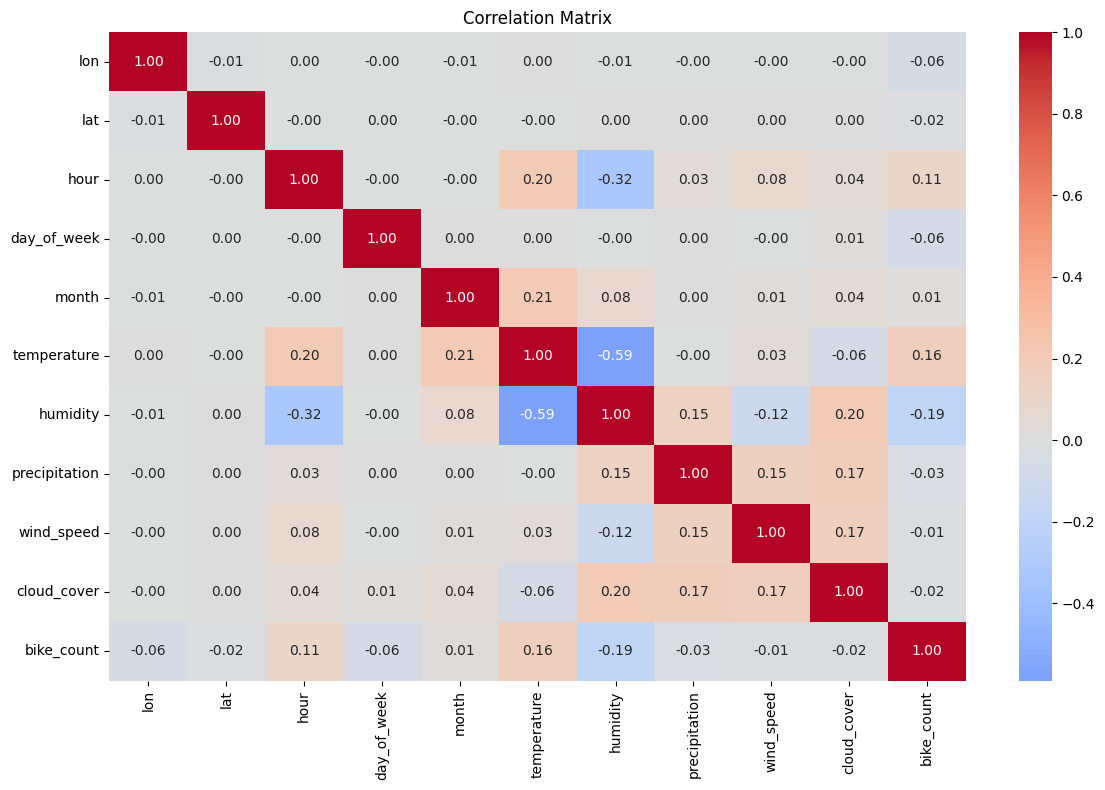

In [32]:
# check if this could be the correlation

import seaborn as sns
import matplotlib.pyplot as plt

corr = merged[["lon", "lat", "hour", "day_of_week", "month",
               "temperature", "humidity", "precipitation", 
               "wind_speed", "cloud_cover", "bike_count"]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Not that much correlation: will remove is_weekend anyway since not important from feature importance earlier; temperature and humidity only- pretty ok- no need for PCA - will get uninterpretable results 

What might help:
- add long lat as input so model doesn't depend that much on site id